**Learning Objectives**

* Understand and apply image enhancement  
* Use binarization and contrast enhancement in preprocessing.
* Utilize smoothing to reduce noise.

# Binarization - Global and adaptive thresholding

* Adaptive thresholding dynamically determines the threshold for each pixel based on the pixel's local neighborhood.  
* This is especially useful for images with varying lighting conditions or uneven illumination.


The process involves three main steps:

**1.Local Neighborhood Selection:**

  * For each pixel, define a square block (e.g., 11×11 pixels) around it.
  * The size of this block is specified by the `blockSize` parameter.  
  * Larger blocks consider more pixels and provide smoother results, but they may miss small details


**2. Threshold Calculation:**

  * Based on the pixel intensities in the block, compute a threshold for the central pixel using one of the following methods:
  * Mean Method (`ADAPTIVE_THRESH_MEAN_C`): Compute the average intensity of all pixels in the block.
  * Subtract a constant `C` from the computed value to fine-tune the threshold

**3. Pixel Classification:**

  * Compare the intensity of the central pixel to the computed threshold
  * If pixel intensity>threshold, set it to *white (255)*.
  * Otherwise, set it to *black (0)*.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import cv2
from google.colab.patches import cv2_imshow # Import cv2_imshow for displaying images in Colab
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# Load a grayscale image
image = cv2.imread('/content/drive/MyDrive/Sample_Images/x-ray.jpg', 0) #0 indicated grayscale
cv2_imshow(image)

In [ ]:
# Global Thresholding
_, global_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)


In [ ]:
help(cv2.adaptiveThreshold)

In [ ]:
# Display the results

titles = ['Original', 'Global Thresholding', 'Adaptive Thresholding']
images = [image, global_thresh, adaptive_thresh]

for i in range(3):
  plt.subplot(1, 3, i+1) # number of rows, columns, and index value
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
  plt.show()

**Step-by-Step Breakdown**

 **Load the Image:**
The input image is read in grayscale mode (0).

**Global Thresholding:**

* A single **threshold (127)** is applied to the entire image.
* This works well only if the lighting is uniform.

**Adaptive Mean Thresholding:**

* Calculates the mean intensity of the neighborhood (`11x11` in this case).
* Subtracts `C=2` from the computed mean to determine the threshold for each pixel

# Adaptive Thresholding: Fine-Tuning Parameters

**blockSize:**

  * Larger values consider a broader neighborhood, smoothing details.  
  * Smaller values preserve fine details but may retain noise.

**C**

  * Adjusts the threshold offset.  
  * Positive values darken the output,  
  * Negative values lighten it.

**Example with C=2**

**Neighborhood Mean Calculation:**

  * For a `5×5×5` block centered on pixel `(𝑥,𝑦)`:
  * Mean intensity value of the `neighborhood = 128`
  * Subtracted constant `C=2`
  * Threshold = `128−2=126`

**Pixel Comparison:**  
  * If the intensity of pixel `(𝑥,𝑦)` is greater than `126`, it is set to *white (255)*.
  * Otherwise, it is set to *black (0)*.

In [ ]:
# Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 5, 2)

# Display the results

titles = ['Original', 'Global Thresholding', 'Adaptive Thresholding']
images = [image, global_thresh, adaptive_thresh]

for i in range(3):
  plt.subplot(1, 3, i+1) # number of rows, columns, and index value
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
  plt.show()

In [ ]:
# Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 5, -5)

# Display the results

titles = ['Original', 'Global Thresholding', 'Adaptive Thresholding']
images = [image, global_thresh, adaptive_thresh]

for i in range(3):
  plt.subplot(1, 3, i+1) # number of rows, columns, and index value
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
  plt.show()

# Contrast Enhancement – Histogram Equalization & Contrast Stretching

Contrast is a measure of the “range” of an image; i.e. how spread its intensities are.

It has many formal definitions one famous is **Michelson’s**:

`𝐶𝑜𝑛𝑡𝑟𝑎𝑠𝑡 = (𝐼𝑚𝑎𝑥 −𝐼𝑚𝑖𝑛) / (𝐼𝑚𝑎𝑥+𝐼𝑚𝑖𝑛) `

* **Contrast Stretching** and **Histogram Equalisation** have the same goal: making the images to use entire range of values available to them.

* **Contrast stretching** is all about increasing the difference between the `maximum intensity` value in an image and the `minimum` one. All the rest of the intensity values are spread out between this range.

* **Histogram equalization** is about modifying the intensity values of all the pixels in the image such that the histogram is "flattened" (in reality, the histogram can't be exactly flattened, there would be some peaks and some valleys, but that's a practical problem).

# Histogram Equalization and Contrast Stretching- Code Example

In [ ]:
# Histogram Equalization
equalized = cv2.equalizeHist(image)


In [ ]:
# Contrast Stretching
min_val, max_val = np.percentile(image, (2, 98))
stretched = np.clip((image - min_val) / (max_val - min_val) * 255, 0, 255).astype(np.uint8)

`(2, 98)` = "Ignore the 2% extremes on each end,
            stretch everything in the middle to fill 0→255"

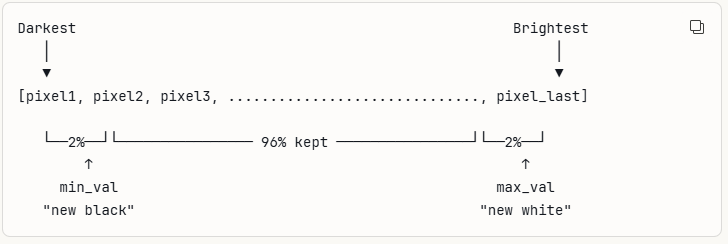

In [ ]:
# Display the results
titles = ['Original', 'Histogram Equalization', 'Contrast Stretching']
images = [image, equalized, stretched]

# Create a figure with subplots for images and histograms

fig, axes = plt.subplots(2, 3, figsize=(12, 6))  # 2 rows, 3 columns
for i in range(3):
  # Display image
  axes[0, i].imshow(images[i], cmap='gray')  # axes[row,column]
  axes[0, i].set_title(titles[i])
  axes[0, i].axis('off')

  # Display histogram
  axes[1, i].hist(images[i].ravel(), 256, [0, 256])
  axes[1, i].set_title(f'Histogram of {titles[i]}')
  plt.tight_layout()  # Adjust subplot parameters for a tight layout

# Example Input and Output

**Input Image:** An underexposed image with intensity values concentrated in the low range.

**Process:**

* Suppose the 2nd percentile is 50 and the 98th percentile is 200.
* Contrast stretching maps pixel intensities as follows:
* 50 → 0 (black)
* 200 → 255 (white)
* Values between 50 and 200 are linearly interpolated.

**Output Image:**

The stretched image will now use the full dynamic range [0, 255], improving the visibility of details.

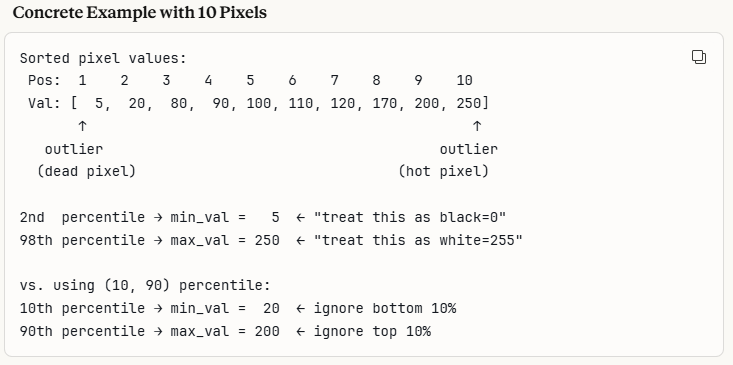

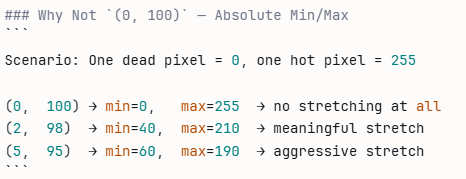

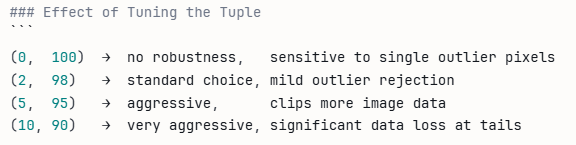

# Smoothing- Mean & Median Filter

* Smoothing is a fundamental image processing operation that reduces noise and smoothens intensity variations in an image.  

* It achieves this by averaging or modifying pixel values based on their neighbours, resulting in a cleaner and more visually appealing image.

* The **mean filter** replaces each pixel's value with the average of its neighbouring pixel values within a specified window size.

* The **median filter** replaces each pixel value with the median of the values in its neighbourhood. It is particularly effective at removing "salt-and-pepper noise" (random bright and dark spots).

# Mean Filter

A kernel (e.g., `3×3` or `5×5`) is moved over the image pixel by pixel.

For each position of the kernel:
  * Compute the arithmetic mean of all pixel values in the kernel.

  * Replace the center pixel of the kernel with this computed mean.

**Advantages**

  * Simple and computationally inexpensive.
  * Effective for reducing random noise (e.g., salt-and-pepper noise).

**Disadvantages**

  * Blurs edges since it averages all pixel values, regardless of whether they belong to edges or not.

# Median Filter

* A kernel of a specified size is centered on each pixel.
* All pixel values within the kernel are sorted in ascending order.
* The median value (middle value in the sorted list) is assigned to the center pixel.

**Advantages**

* Preserves edges better than the mean filter.
* Highly effective at removing salt-and-pepper noise without significantly blurring the image.

**Disadvantages**

* More computationally expensive than the mean filter.
* Less effective at reducing Gaussian noise.

# Mean & Median Filter – Code Example

In [ ]:
# mean Filter
mean_filtered = cv2.blur(image, (11, 11))  # Kernel size 11x11

# median Filter
median_filtered = cv2.medianBlur(image, 11)  # Kernel size 11x11

# Display the results

titles = ['Original', 'Mean Filter', 'Median Filter']
images = [image, mean_filtered, median_filtered]

for i in range(3):
  plt.subplot(1, 3, i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
plt.show()

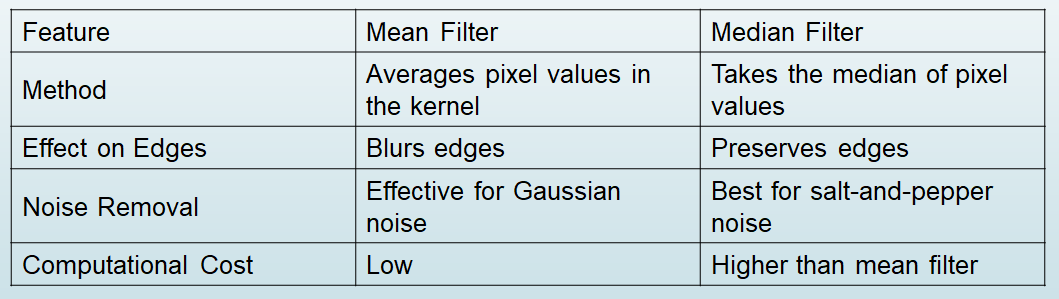

**----------- END ------------**